In [ ]:
%pip install scikit-learn

In [38]:
import polars as pl 
import seaborn as sns 
import matplotlib.pyplot as plt

# aprendiado de maquina e preparação 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings

<function warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

In [2]:
ARQUIVO = r'C:\analise de dados\03.BaseDPEvolucaoMensalCisp.csv'

***CORRELAÇÃO***

In [ ]:
df=pl.read_csv(ARQUIVO, separator=';', encoding='iso-8859-1')
df.columns

In [ ]:
#categoria -> transformar Strings que se repetem em categorias

df = df.with_columns(
    pl.col('munic').cast(pl.Categorical),
    pl.col('regiao').cast(pl.Categorical)
)

In [6]:
COLUNA1 = 'roubo_veiculo'
COLUNA2 = 'recuperacao_veiculos'

In [8]:
correlacao = df.select(
    pl.corr(COLUNA1, COLUNA2)
).item()
print(f'Correlação: {correlacao:.4f}')

Correlação: 0.8455


In [ ]:
#agrupar por região
df_regiao_agg= df.group_by('regiao').agg(
        [
            pl.mean(COLUNA1).alias(f'Média da {COLUNA1}'),
            pl.mean(COLUNA2).alias(f'Média da {COLUNA2}'),
        ]
)
df_regiao_agg.select(
    pl.corr(f'Média da {COLUNA1}', f'Média da {COLUNA2}')
)

Média da roubo_veiculo
f64
0.984596


In [17]:
#agrupar por municipio
df_munic_agg= df.group_by('munic').agg(
        [
            pl.mean(COLUNA1).alias(f'Média da {COLUNA1}'),
            pl.mean(COLUNA2).alias(f'Média da {COLUNA2}'),
        ]
)
df_munic_agg.select(
    pl.corr(f'Média da {COLUNA1}', f'Média da {COLUNA2}')
)

Média da roubo_veiculo
f64
0.974349


<Axes: >

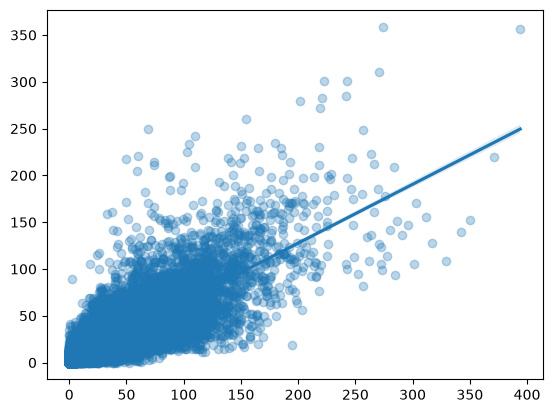

In [ ]:
sns.regplot(
    data=df,
    x=COLUNA1,
    y=COLUNA2,
    scatter_kws={'alpha':0.3}
)

***REGRESSÃO LINEAR***

In [27]:
# ML (Machine Learning)
df2 = df.select(COLUNA1, COLUNA2).drop_nans()
# Colunas devem ter o mesmo tamanho (# de linhas)
x = df2.select(COLUNA1)
y = df2.select(COLUNA2)
#normalizar a escala do X 
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
# fit_transform -> fit = treino -- transform -> aplicar no x 

In [28]:
# dividir entre treino e teste 
X_treino, x_teste, y_treino, y_teste = ( 
    train_test_split(x_scaled, y, test_size=0.2, random_state=42)
)

In [29]:
# treinar o modelo 
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[245.09]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[2.08]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[14.11]


In [31]:
# testar o modelo 
y_pred = modelo.predict(x_teste)
# verificar o quao bom esta o modelo linear -> oq ele deveria prever vs o que ele previu 
r2 = r2_score(y_teste, y_pred)

print(f'r2 score: {r2:.4f}')
print(f'Coeficiente Angular (a) : {modelo.coef_[0, 0]:.4f}')
print(f'Intercepto (b): {modelo.intercept_[0]:.4f}')

r2 score: 0.7059
Coeficiente Angular (a) : 245.0897
Intercepto (b): 2.0800


In [37]:
#"Novo dado"
novo_dado = 150
novo_dado_scaled = scaler.transform([[novo_dado]])
previsao = modelo.predict(novo_dado_scaled)
print(f'Para {novo_dado} de {COLUNA1} haverá:\n {previsao[0, 0]:.2f} ocorrencias de {COLUNA2}')

Para 150 de roubo_veiculo haverá:
 95.39 ocorrencias de recuperacao_veiculos


c:\analise de dados\virtual\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
